In [1]:
import pybamm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.interpolate import interp1d
import random
import functools
import matplotlib as mpl
import plotly.graph_objects as go
import pickle
from plotly.subplots import make_subplots
from joblib import Parallel, delayed


from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze


import gc
gc.collect()

import logging
# Set the logging level to ERROR to suppress warnings
pybamm.set_logging_level("ERROR")

from utils import *
# from simplify import *

%load_ext autoreload
%autoreload 2

c:\Users\ljw76\anaconda3\envs\PyBaMM-RO9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Local (sDAE)

2026-06-12 17:39:01.788 - [ERROR] callbacks.on_experiment_error(235): Simulation error: IDA_CONV_FAIL: Convergence test failures occurred too many times during one step or with |h| = hmin


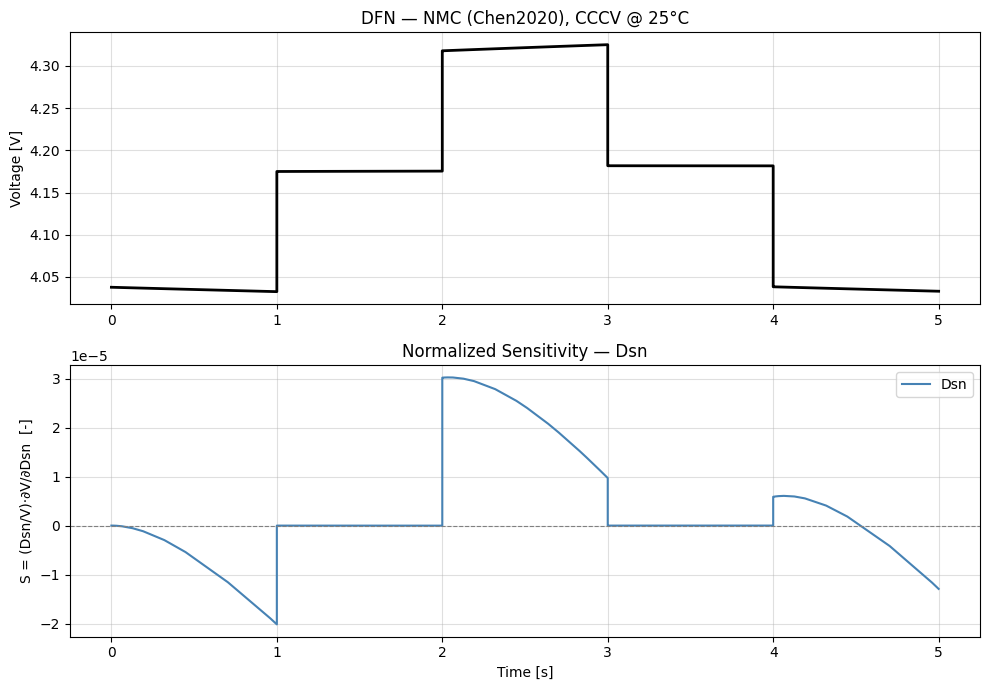

In [2]:
model = pybamm.lithium_ion.DFN()
base_param = pybamm.ParameterValues("Chen2020")

soc=0.5
soc2theta_n, soc2theta_p = build_soc2theta(base_param.copy())
c_n_init, c_p_init = soc2conc(soc, base_param, soc2theta_n, soc2theta_p)
experiment = make_experiment(profile_id=2, soc=soc)


input_param_name = "Negative electrode diffusivity [m2.s-1]"
input_param_value = base_param[input_param_name]
base_param.update({input_param_name: "[input]"})

solver = pybamm.IDAKLUSolver()


sim = pybamm.Simulation(
    model,
    experiment=experiment,
    solver=solver,
    parameter_values=base_param,
)

sol = sim.solve(
    inputs={input_param_name: input_param_value},
    calculate_sensitivities=True,
)


t = sol["Time [s]"].entries
V = sol["Voltage [V]"].entries
sens = sol["Voltage [V]"].sensitivities[input_param_name]
S = (input_param_value / V) * sens

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(t, V, "k-", linewidth=2)
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title("DFN — NMC (Chen2020), CCCV @ 25°C")
axes[0].grid(True, alpha=0.4)

axes[1].plot(t, S, color="steelblue", linewidth=1.5, label="Dsn")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("S = (Dsn/V)·∂V/∂Dsn  [-]")
axes[1].set_title("Normalized Sensitivity — Dsn")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# --- 음극 ---
c_n_bulk = sol["Average negative particle concentration [mol.m-3]"].entries
sens_n = sol["Average negative particle concentration [mol.m-3]"].sensitivities[input_param_name]
S_n = (input_param_value / c_n_bulk) * sens_n  # normalized

# --- 양극 ---
c_p_bulk = sol["Average positive particle concentration [mol.m-3]"].entries
sens_p = sol["Average positive particle concentration [mol.m-3]"].sensitivities[input_param_name]
S_p = (input_param_value / c_p_bulk) * sens_p  # normalized



fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# c_n_bulk, c_p_bulk
axes[0].plot(t, c_n_bulk, color="tab:blue", linewidth=1.8)
axes[0].set_ylabel(r"$\bar{c}_s^-$ [mol/m³]", color="tab:blue")
axes[0].tick_params(axis="y", labelcolor="tab:blue")
ax0r = axes[0].twinx()
ax0r.plot(t, c_p_bulk, color="tab:red", linewidth=1.8)
ax0r.set_ylabel(r"$\bar{c}_s^+$ [mol/m³]", color="tab:red")
ax0r.tick_params(axis="y", labelcolor="tab:red")
axes[0].set_title("Bulk concentrations")
axes[0].grid(True, alpha=0.4)

# S_n
axes[1].plot(t, S_n, color="tab:blue", linewidth=1.5)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylabel(r"$S_n = (D_{sn}/\bar{c}_s^-)\,\partial \bar{c}_s^-/\partial D_{sn}$  [-]")
axes[1].set_title("Normalized sensitivity — anode bulk concentration")
axes[1].grid(True, alpha=0.4)

# S_p
axes[2].plot(t, S_p, color="tab:red", linewidth=1.5)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel(r"$S_p = (D_{sn}/\bar{c}_s^+)\,\partial \bar{c}_s^+/\partial D_{sn}$  [-]")
axes[2].set_title("Normalized sensitivity — cathode bulk concentration")
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# import pybamm
# import numpy as np

# param_labels = {
#     "Negative electrode exchange-current density [A.m-2]": r"$k^-$",
#     "Positive electrode exchange-current density [A.m-2]": r"$k^+$",
#     "Negative electrode double-layer capacity [F.m-2]": r"$C_{dl}^-$",
#     "Positive electrode double-layer capacity [F.m-2]": r"$C_{dl}^+$",
#     "Negative electrode active material volume fraction": r"$\varepsilon_s^-$",
#     "Positive electrode active material volume fraction": r"$\varepsilon_s^+$",
#     "Cation transference number": r"$t^+$",
#     "Electrolyte conductivity [S.m-1]": r"$\kappa$",
#     "Electrolyte diffusivity [m2.s-1]": r"$D_e$",
#     "Positive electrode porosity": r"$\varepsilon_e^+$",
#     "Negative electrode porosity": r"$\varepsilon_e^-$",
#     "Separator porosity": r"$\varepsilon_e^{sep}$",
#     "Negative electrode thickness [m]": r"$L^-$",
#     "Positive electrode thickness [m]": r"$L^+$",
#     "Separator thickness [m]": r"$L^{sep}$",
#     "Negative particle diffusivity [m2.s-1]": r"$D_s^-$",
#     "Negative particle radius [m]": r"$R_s^-$",
#     "Positive particle diffusivity [m2.s-1]": r"$D_s^+$",
#     "Positive particle radius [m]": r"$R_s^+$",
#     "Negative electrode conductivity [S.m-1]": r"$\sigma^-$",
#     "Positive electrode conductivity [S.m-1]": r"$\sigma^+$",
# }

# param_names = list(param_labels.keys())


# results = {}

# for pname, label in param_labels.items():
#     try:
#         param = pybamm.ParameterValues("Chen2020")
#         param["Contact resistance [Ohm]"] = 0.005
#         param.update({pname: "[input]"})
#         input_val = pybamm.ParameterValues("Chen2020")[pname]
#         if callable(input_val):
#             input_val = 1.0

#         model = pybamm.lithium_ion.DFN(options={
#             "surface form": "differential",
#             "contact resistance": "true",
#         })
#         solver = pybamm.IDAKLUSolver()
#         experiment = pybamm.Experiment(["Discharge at 1C until 2.5 V"])
#         sim = pybamm.Simulation(model, parameter_values=param, solver=solver, experiment=experiment)

#         sol = sim.solve(
#             inputs={pname: input_val},
#             calculate_sensitivities=True,
#         )

#         sens = sol["Voltage [V]"].sensitivities[pname]
#         max_val = np.max(np.abs(sens))
#         results[pname] = 1
#         print(f"✅ {label}: OK (max={max_val:.3e})")

#     except Exception as e:
#         results[pname] = 0
#         print(f"❌ {label}: FAIL — {str(e)[:60]}")

# print("\n=== 결과 요약 ===")
# for pname, ok in results.items():
#     print(f"{'✅' if ok else '❌'} {param_labels[pname]}: {ok}")

### test constant-style De, kappa, kp, kn

In [ ]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

experiment = make_experiment(profile_id=4, soc=0.5)

# Reference solve
p_ref = pybamm.ParameterValues("Chen2020")
model = pybamm.lithium_ion.DFN()
sim_ref = pybamm.Simulation(model, experiment=experiment,
                             parameter_values=p_ref,
                             solver=pybamm.IDAKLUSolver())
sol_ref = sim_ref.solve()

t_ref = sol_ref["Time [s]"].entries
V_ref = sol_ref["Voltage [V]"].entries

print(f"Reference: {len(t_ref)} time points, V range [{V_ref.min():.4f}, {V_ref.max():.4f}] V")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# State variables
c_e_all    = sol_ref["Electrolyte concentration [mol.m-3]"].entries
c_e_n      = sol_ref["Negative electrolyte concentration [mol.m-3]"].entries
c_e_p      = sol_ref["Positive electrolyte concentration [mol.m-3]"].entries
c_s_surf_n = sol_ref["Negative particle surface concentration [mol.m-3]"].entries
c_s_surf_p = sol_ref["Positive particle surface concentration [mol.m-3]"].entries
x_all      = sol_ref["x [m]"].entries
x_n        = sol_ref["x_n [m]"].entries
x_p        = sol_ref["x_p [m]"].entries
t          = sol_ref["Time [s]"].entries

T_const = 298.15
R_gas   = 8.314462618
c_s_max_n = p_ref["Maximum concentration in negative electrode [mol.m-3]"]
c_s_max_p = p_ref["Maximum concentration in positive electrode [mol.m-3]"]

# --- Chen2020 함수들 직접 평가 ---
# κ(c_e) - Nyman2008
kappa_xt = (
    0.1297*(c_e_all/1000)**3 
    - 2.51*(c_e_all/1000)**1.5 
    + 3.329*(c_e_all/1000)
)

# D_e(c_e) - Nyman2008
De_xt = (
    8.794e-11*(c_e_all/1000)**2 
    - 3.972e-10*(c_e_all/1000) 
    + 4.862e-10
)

# j_0^- (negative electrode region only)
arrh_n = np.exp(35000/R_gas * (1/298.15 - 1/T_const))   # = 1 since T = 298.15
j0_n_xt = (
    6.48e-7 * arrh_n 
    * c_e_n**0.5 * c_s_surf_n**0.5 * (c_s_max_n - c_s_surf_n)**0.5
)

# j_0^+ (positive electrode region only)
arrh_p = np.exp(17800/R_gas * (1/298.15 - 1/T_const))   # = 1 since T = 298.15
j0_p_xt = (
    3.42e-6 * arrh_p 
    * c_e_p**0.5 * c_s_surf_p**0.5 * (c_s_max_p - c_s_surf_p)**0.5
)

# --- Shape 확인 ---
print(f"kappa_xt : {kappa_xt.shape}    range [{kappa_xt.min():.3e}, {kappa_xt.max():.3e}] S/m")
print(f"De_xt    : {De_xt.shape}    range [{De_xt.min():.3e}, {De_xt.max():.3e}] m²/s")
print(f"j0_n_xt  : {j0_n_xt.shape}    range [{j0_n_xt.min():.3e}, {j0_n_xt.max():.3e}] A/m²")
print(f"j0_p_xt  : {j0_p_xt.shape}    range [{j0_p_xt.min():.3e}, {j0_p_xt.max():.3e}] A/m²")



In [13]:
# ══════════════════════════════════════════════════════════════
# STEP 0 — Reference simulation (Chen2020 default, 변경 없음)
# ══════════════════════════════════════════════════════════════
t_eval = np.linspace(0, 3001, 3002)

experiment = make_experiment(profile_id=4, soc=0.5)

p_ref = pybamm.ParameterValues("Chen2020")
model_ref = pybamm.lithium_ion.DFN()
sim_ref = pybamm.Simulation(model_ref, experiment=experiment,
                             parameter_values=p_ref,
                             solver=pybamm.IDAKLUSolver())
sol_ref = sim_ref.solve(t_eval=t_eval)

t_ref = sol_ref["Time [s]"].entries
V_ref = sol_ref["Voltage [V]"].entries

print(f"Reference: {len(t_ref)} time points, V range [{V_ref.min():.4f}, {V_ref.max():.4f}] V")


# ══════════════════════════════════════════════════════════════
# STEP 1 — Nominal values from utils
# ══════════════════════════════════════════════════════════════
kappa_nominal, De_nominal, m_ref_neg_nominal, m_ref_pos_nominal = get_nominals()

print(f"κ nominal:      {kappa_nominal:.4e} S/m")
print(f"D_e nominal:    {De_nominal:.4e} m²/s")
print(f"m_ref^- nominal: {m_ref_neg_nominal:.4e}")
print(f"m_ref^+ nominal: {m_ref_pos_nominal:.4e}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — Variant 검증
# ══════════════════════════════════════════════════════════════
variants = [
    ("κ const",        [apply_kappa],              None),
    ("D_e const",      [apply_De],                 None),
    ("j₀⁻ custom",     [apply_j0n],
     {"Negative electrode exchange-current density [A.m-2]": m_ref_neg_nominal}),
    ("j₀⁺ custom",     [apply_j0p],
     {"Positive electrode exchange-current density [A.m-2]": m_ref_pos_nominal}),
    ("All 4",          [apply_kappa, apply_De, apply_j0n, apply_j0p],
     get_base_inputs()),
]


results = {}

for label, modifiers, inputs in variants:
    p = pybamm.ParameterValues("Chen2020")
    for mod in modifiers:
        mod(p)
    
    try:
        model = pybamm.lithium_ion.DFN()
        sim = pybamm.Simulation(model, experiment=experiment,
                                 parameter_values=p,
                                 solver=pybamm.IDAKLUSolver())
        sol = sim.solve(t_eval=t_eval) if inputs is None else \
              sim.solve(inputs=inputs, t_eval=t_eval)
        
        V = sol["Voltage [V]"].entries
        t = sol["Time [s]"].entries
        
        V_ref_at_t = interp1d(t_ref, V_ref, kind='linear',
                              fill_value='extrapolate', bounds_error=False)(t)
        dV = V - V_ref_at_t
        
        results[label] = {
            "t": t, "V": V, "dV": dV,
            "dV_max": np.max(np.abs(dV))*1000,
            "dV_rmse": np.sqrt(np.mean(dV**2))*1000,
        }
        print(f"[{label:18s}]  ΔV_max = {results[label]['dV_max']:7.3f} mV   "
              f"ΔV_RMSE = {results[label]['dV_rmse']:7.3f} mV")
    except Exception as e:
        results[label] = None
        print(f"[{label:18s}]  FAILED — {str(e)[:80]}")


# ══════════════════════════════════════════════════════════════
# 시각화 — Plotly interactive
# ══════════════════════════════════════════════════════════════
n_var = len(variants)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig = make_subplots(
    rows=2, cols=n_var,
    shared_xaxes=True,
    vertical_spacing=0.10,
    horizontal_spacing=0.05,
    subplot_titles=[v[0] for v in variants] + 
                   [f"ΔV: {v[0]}" for v in variants],
)

for i, (label, _, _) in enumerate(variants):
    res = results.get(label)
    col = i + 1
    
    if res is None:
        fig.add_annotation(text="FAILED", row=1, col=col, showarrow=False)
        continue
    
    fig.add_trace(
        go.Scatter(x=t_ref, y=V_ref, mode='lines', name='Ref',
                   line=dict(color='black', width=1.5),
                   showlegend=(i == 0), legendgroup='ref'),
        row=1, col=col,
    )
    fig.add_trace(
        go.Scatter(x=res["t"], y=res["V"], mode='lines', name=label,
                   line=dict(color=colors[i], width=1.2, dash='dash'),
                   showlegend=True),
        row=1, col=col,
    )
    
    fig.add_trace(
        go.Scatter(x=res["t"], y=res["dV"]*1000, mode='lines',
                   line=dict(color=colors[i], width=1.2),
                   showlegend=False,
                   hovertemplate='t=%{x:.1f}s<br>ΔV=%{y:.3f} mV<extra></extra>'),
        row=2, col=col,
    )
    fig.add_hline(y=0, line=dict(color='gray', dash='dash', width=0.5),
                  row=2, col=col)
    
    fig.layout.annotations[n_var + i].update(
        text=f"max={res['dV_max']:.2f} mV, rmse={res['dV_rmse']:.2f} mV"
    )

for col in range(1, n_var + 1):
    fig.update_xaxes(title_text="Time [s]", row=2, col=col)
fig.update_yaxes(title_text="V [V]", row=1, col=1)
fig.update_yaxes(title_text="ΔV [mV]", row=2, col=1)

fig.update_layout(
    height=700, width=300*n_var,
    hovermode='x unified',
    title_text="V trajectory & ΔV comparison",
)

fig.show()

Reference: 248 time points, V range [4.0022, 4.3817] V
κ nominal:      9.4870e-01 S/m
D_e nominal:    1.7694e-10 m²/s
m_ref^- nominal: 6.4800e-07
m_ref^+ nominal: 3.4200e-06
[κ const           ]  ΔV_max =   0.107 mV   ΔV_RMSE =   0.036 mV
[D_e const         ]  ΔV_max =   0.677 mV   ΔV_RMSE =   0.291 mV
[j₀⁻ custom        ]  ΔV_max =   0.000 mV   ΔV_RMSE =   0.000 mV
[j₀⁺ custom        ]  ΔV_max =   0.000 mV   ΔV_RMSE =   0.000 mV
[All 4             ]  ΔV_max =   0.623 mV   ΔV_RMSE =   0.283 mV


### dV/dtheta

In [3]:
# ══════════════════════════════════════════════════════════════
# 0. Nominal 값 + 함수 정의
# ══════════════════════════════════════════════════════════════
c_e_ref = 1000.0
T_ref_K = 298.15

_p_tmp = pybamm.ParameterValues("Chen2020")
kappa_nominal     = float(_p_tmp["Electrolyte conductivity [S.m-1]"](c_e_ref, T_ref_K))
De_nominal        = float(_p_tmp["Electrolyte diffusivity [m2.s-1]"](c_e_ref, T_ref_K))
m_ref_neg_nominal = 6.48e-7
m_ref_pos_nominal = 3.42e-6


# j0 함수 — m_ref 가 상수 (input 아님)
def j0_neg_const(c_e, c_s_surf, c_s_max, T):
    arrh = pybamm.exp(35000 / pybamm.constants.R * (1/298.15 - 1/T))
    return m_ref_neg_nominal * arrh * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5

def j0_pos_const(c_e, c_s_surf, c_s_max, T):
    arrh = pybamm.exp(17800 / pybamm.constants.R * (1/298.15 - 1/T))
    return m_ref_pos_nominal * arrh * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5


# j0 함수 — m_ref 가 InputParameter (k± sensitivity 볼 때만 사용)
def j0_neg_with_mref(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("Negative electrode exchange-current density [A.m-2]")
    arrh = pybamm.exp(35000 / pybamm.constants.R * (1/298.15 - 1/T))
    return m_ref * arrh * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5

def j0_pos_with_mref(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("Positive electrode exchange-current density [A.m-2]")
    arrh = pybamm.exp(17800 / pybamm.constants.R * (1/298.15 - 1/T))
    return m_ref * arrh * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5


print(f"κ nominal:       {kappa_nominal:.4e}")
print(f"D_e nominal:     {De_nominal:.4e}")
print(f"m_ref^- nominal: {m_ref_neg_nominal:.4e}")
print(f"m_ref^+ nominal: {m_ref_pos_nominal:.4e}")


# ══════════════════════════════════════════════════════════════
# 1. Base parameter set — 4개 callable 다 박아둠
# ══════════════════════════════════════════════════════════════
p_ref = pybamm.ParameterValues("Chen2020")
p_ref["Electrolyte conductivity [S.m-1]"]                 = kappa_nominal
p_ref["Electrolyte diffusivity [m2.s-1]"]                 = De_nominal
p_ref["Negative electrode exchange-current density [A.m-2]"] = j0_neg_const
p_ref["Positive electrode exchange-current density [A.m-2]"] = j0_pos_const
p_ref["Contact resistance [Ohm]"]                         = 0.005

# 이 base 자체는 inputs 없이 simulation 가능

# 한 줄로 SOC 적용
set_init_concentration(p_ref, 0.6)

print(f"Initial c_n = {p_ref['Initial concentration in negative electrode [mol.m-3]']:.2f}")
print(f"Initial c_p = {p_ref['Initial concentration in positive electrode [mol.m-3]']:.2f}")

# ══════════════════════════════════════════════════════════════
# 2. Parameter labels + 분류
# ══════════════════════════════════════════════════════════════
param_labels = {
    "Negative electrode exchange-current density [A.m-2]": r"$k^-$",
    "Positive electrode exchange-current density [A.m-2]": r"$k^+$",
    "Negative electrode double-layer capacity [F.m-2]":    r"$C_{dl}^-$",
    "Positive electrode double-layer capacity [F.m-2]":    r"$C_{dl}^+$",
    "Negative electrode active material volume fraction":  r"$\varepsilon_s^-$",
    "Positive electrode active material volume fraction":  r"$\varepsilon_s^+$",
    "Cation transference number":                          r"$t^+$",
    "Electrolyte conductivity [S.m-1]":                    r"$\kappa$",
    "Electrolyte diffusivity [m2.s-1]":                    r"$D_e$",
    "Positive electrode porosity":                         r"$\varepsilon_e^+$",
    "Negative electrode porosity":                         r"$\varepsilon_e^-$",
    "Separator porosity":                                  r"$\varepsilon_e^{sep}$",
    "Negative electrode thickness [m]":                    r"$L^-$",
    "Positive electrode thickness [m]":                    r"$L^+$",
    "Separator thickness [m]":                             r"$L^{sep}$",
    "Negative particle diffusivity [m2.s-1]":              r"$D_s^-$",
    "Positive particle diffusivity [m2.s-1]":              r"$D_s^+$",
    "Negative electrode conductivity [S.m-1]":             r"$\sigma^-$",
    "Positive electrode conductivity [S.m-1]":             r"$\sigma^+$",
    "Negative particle radius [m]":                        r"$R_s^-$",
    "Positive particle radius [m]":                        r"$R_s^+$",
}
param_names = list(param_labels.keys())

mesh_dependent = [
    "Negative electrode thickness [m]",
    "Positive electrode thickness [m]",
    "Separator thickness [m]",
    "Negative particle radius [m]",
    "Positive particle radius [m]",
]

K_NEG = "Negative electrode exchange-current density [A.m-2]"
K_POS = "Positive electrode exchange-current density [A.m-2]"

sdae_params = [k for k in param_names if k not in mesh_dependent]


# ══════════════════════════════════════════════════════════════
# 3. Experiment + model options
# ══════════════════════════════════════════════════════════════
experiment = make_experiment(profile_id='hppc', soc=0.6)

MODEL_OPTIONS = {
    "surface form": "differential",
    "contact resistance": "true",
}

t_uniform = np.linspace(0, 3001, 3002)
# t_uniform = np.linspace(0, 1700, 1701)


# ══════════════════════════════════════════════════════════════
# 4. Sensitivity loop — target 하나씩, input 1개
# ══════════════════════════════════════════════════════════════
sdae_sensitivity = {}
sdae_sens_ts    = {}        # ← 추가: time-series 저장

for name in sdae_params:
    t0 = time.time()

    try:
        p = p_ref.copy()
        
        # Target 별로 처리
        if name == K_NEG:
            # j0⁻ 만 input 노출 버전으로 교체
            p[K_NEG] = j0_neg_with_mref
            nominal_val = m_ref_neg_nominal
        elif name == K_POS:
            # j0⁺ 만 input 노출 버전으로 교체
            p[K_POS] = j0_pos_with_mref
            nominal_val = m_ref_pos_nominal
        else:
            # 일반 scalar 파라미터
            val = p[name]
            if callable(val):
                raise ValueError(f"{name} still callable")
            nominal_val = float(val)
            p.update({name: "[input]"})
        
        # Inputs 는 항상 1개 (target 만)
        inputs = {name: nominal_val}
        
        model_ = pybamm.lithium_ion.SPMe(options=MODEL_OPTIONS)
        solver_ = pybamm.IDAKLUSolver()
        sim_ = pybamm.Simulation(model_, experiment=experiment,
                                  parameter_values=p, solver=solver_)
        sol_ = sim_.solve(
            inputs=inputs,
            calculate_sensitivities=True,
        )
        
        V_ = sol_["Voltage [V]"].entries
        t_ = sol_["Time [s]"].entries
        sens = sol_["Voltage [V]"].sensitivities[name].flatten()[:len(V_)]
        
        # Uniform grid 에 interp
        sens_uniform = interp1d(t_, sens, kind='linear',
                                 fill_value='extrapolate',
                                 bounds_error=False)(t_uniform)
        
        # Semi-relative
        S = nominal_val * sens_uniform
        sdae_sensitivity[name] = float(np.sqrt(np.mean(S**2)))
        sdae_sens_ts[name]     = S          # ← 추가
        
        print(f"{param_labels[name]:6s}  S_rms = {sdae_sensitivity[name]:.4e}   "
              f"(nominal = {nominal_val:.3e})")
    
    except Exception as e:
        sdae_sensitivity[name] = np.nan
        sdae_sens_ts[name]     = None       # ← 추가
        print(f"{param_labels[name]:6s}  FAILED — {str(e)[:80]}")


    t1 = time.time()
    print(f"{param_labels[name]:6s}  time = {t1-t0:.2f}s")


# Mesh-dependent → nan
for name in mesh_dependent:
    sdae_sensitivity[name] = np.nan
    sdae_sens_ts[name]     = None           # ← 추가


# ══════════════════════════════════════════════════════════════
# 5. Ranking
# ══════════════════════════════════════════════════════════════
print("\n=== Sensitivity ranking (S_rms, semi-relative) ===")
ranked = sorted(
    [(k, v) for k, v in sdae_sensitivity.items() if not np.isnan(v)],
    key=lambda x: x[1], reverse=True,
)
for pname, s in ranked:
    print(f"  {param_labels[pname]:6s}  {s:.4e}")

print("\nFD-required (not computed):")
for name in mesh_dependent:
    print(f"  {param_labels[name]}")


κ nominal:       9.4870e-01
D_e nominal:     1.7694e-10
m_ref^- nominal: 6.4800e-07
m_ref^+ nominal: 3.4200e-06
Initial c_n = 18280.80
Initial c_p = 31763.19
$k^-$   S_rms = 1.9560e-02   (nominal = 6.480e-07)
$k^-$   time = 1.42s
$k^+$   S_rms = 3.3509e-03   (nominal = 3.420e-06)
$k^+$   time = 1.56s
$C_{dl}^-$  S_rms = 1.6546e-04   (nominal = 2.000e-01)
$C_{dl}^-$  time = 1.35s
$C_{dl}^+$  S_rms = 1.5940e-04   (nominal = 2.000e-01)
$C_{dl}^+$  time = 1.33s
$\varepsilon_s^-$  S_rms = 1.9269e-02   (nominal = 7.500e-01)
$\varepsilon_s^-$  time = 1.61s
$\varepsilon_s^+$  S_rms = 3.5713e-02   (nominal = 6.650e-01)
$\varepsilon_s^+$  time = 2.12s
$t^+$   S_rms = 4.1224e-03   (nominal = 2.594e-01)
$t^+$   time = 1.89s
$\kappa$  S_rms = 4.1978e-03   (nominal = 9.487e-01)
$\kappa$  time = 1.69s
$D_e$   S_rms = 5.6060e-03   (nominal = 1.769e-10)
$D_e$   time = 3.13s
$\varepsilon_e^+$  S_rms = 4.2462e-03   (nominal = 3.350e-01)
$\varepsilon_e^+$  time = 2.06s
$\varepsilon_e^-$  S_rms = 8.8315e-0

In [16]:
def fd_sensitivity(name, frac=0.01):
    """σ± 만 FD 로 계산 — 일반 scalar 파라미터.
    Returns (S_timeseries, S_rms)."""
    p_tmp = p_ref.copy()
    nominal_val = float(p_tmp[name])
    
    def solve_(val):
        p = p_ref.copy()
        p[name] = val
        sim = pybamm.Simulation(
            pybamm.lithium_ion.SPMe(options=MODEL_OPTIONS),
            experiment=experiment,
            parameter_values=p,
            solver=pybamm.IDAKLUSolver()
        )
        sol = sim.solve()
        return sol["Time [s]"].entries, sol["Voltage [V]"].entries
    
    t_p, V_p = solve_(nominal_val * (1 + frac))
    t_m, V_m = solve_(nominal_val * (1 - frac))
    V_p_u = interp1d(t_p, V_p, fill_value='extrapolate', bounds_error=False)(t_uniform)
    V_m_u = interp1d(t_m, V_m, fill_value='extrapolate', bounds_error=False)(t_uniform)
    
    dV_dtheta = (V_p_u - V_m_u) / (2 * frac * nominal_val)
    S = nominal_val * dV_dtheta                                    # time-series
    S_rms = float(np.sqrt(np.mean(S**2)))
    return S, S_rms


# σ± FD 로 덮어쓰기
SIGMA_NEG = "Negative electrode conductivity [S.m-1]"
SIGMA_POS = "Positive electrode conductivity [S.m-1]"

print("\n=== FD correction for σ± ===")
for name in [SIGMA_NEG, SIGMA_POS]:
    S_fd, fd_rms = fd_sensitivity(name)
    old_val = sdae_sensitivity[name]
    sdae_sensitivity[name] = fd_rms
    sdae_sens_ts[name]     = S_fd                                  # ← time-series 도 덮어쓰기
    print(f"  {param_labels[name]:6s}  SDAE={old_val:.4e}  →  FD={fd_rms:.4e}")


# Ranking 다시 출력
print("\n=== Sensitivity ranking (corrected) ===")
ranked = sorted(
    [(k, v) for k, v in sdae_sensitivity.items() if not np.isnan(v)],
    key=lambda x: x[1], reverse=True,
)
for pname, s in ranked:
    print(f"  {param_labels[pname]:6s}  {s:.4e}")


=== FD correction for σ± ===
  $\sigma^-$  SDAE=2.0907e-02  →  FD=3.6914e-03
  $\sigma^+$  SDAE=2.0421e-03  →  FD=4.5776e-03

=== Sensitivity ranking (corrected) ===
  $\varepsilon_s^+$  4.8913e-02
  $\varepsilon_s^-$  4.0478e-02
  $k^-$   1.8130e-02
  $D_s^+$  1.0172e-02
  $\varepsilon_e^-$  8.4806e-03
  $\kappa$  5.2536e-03
  $\sigma^+$  4.5776e-03
  $D_e$   4.3836e-03
  $\sigma^-$  3.6914e-03
  $\varepsilon_e^+$  3.5556e-03
  $k^+$   3.4841e-03
  $t^+$   3.4499e-03
  $\varepsilon_e^{sep}$  1.4376e-03
  $D_s^-$  1.0328e-03
  $C_{dl}^-$  1.6794e-04
  $C_{dl}^+$  2.0066e-05


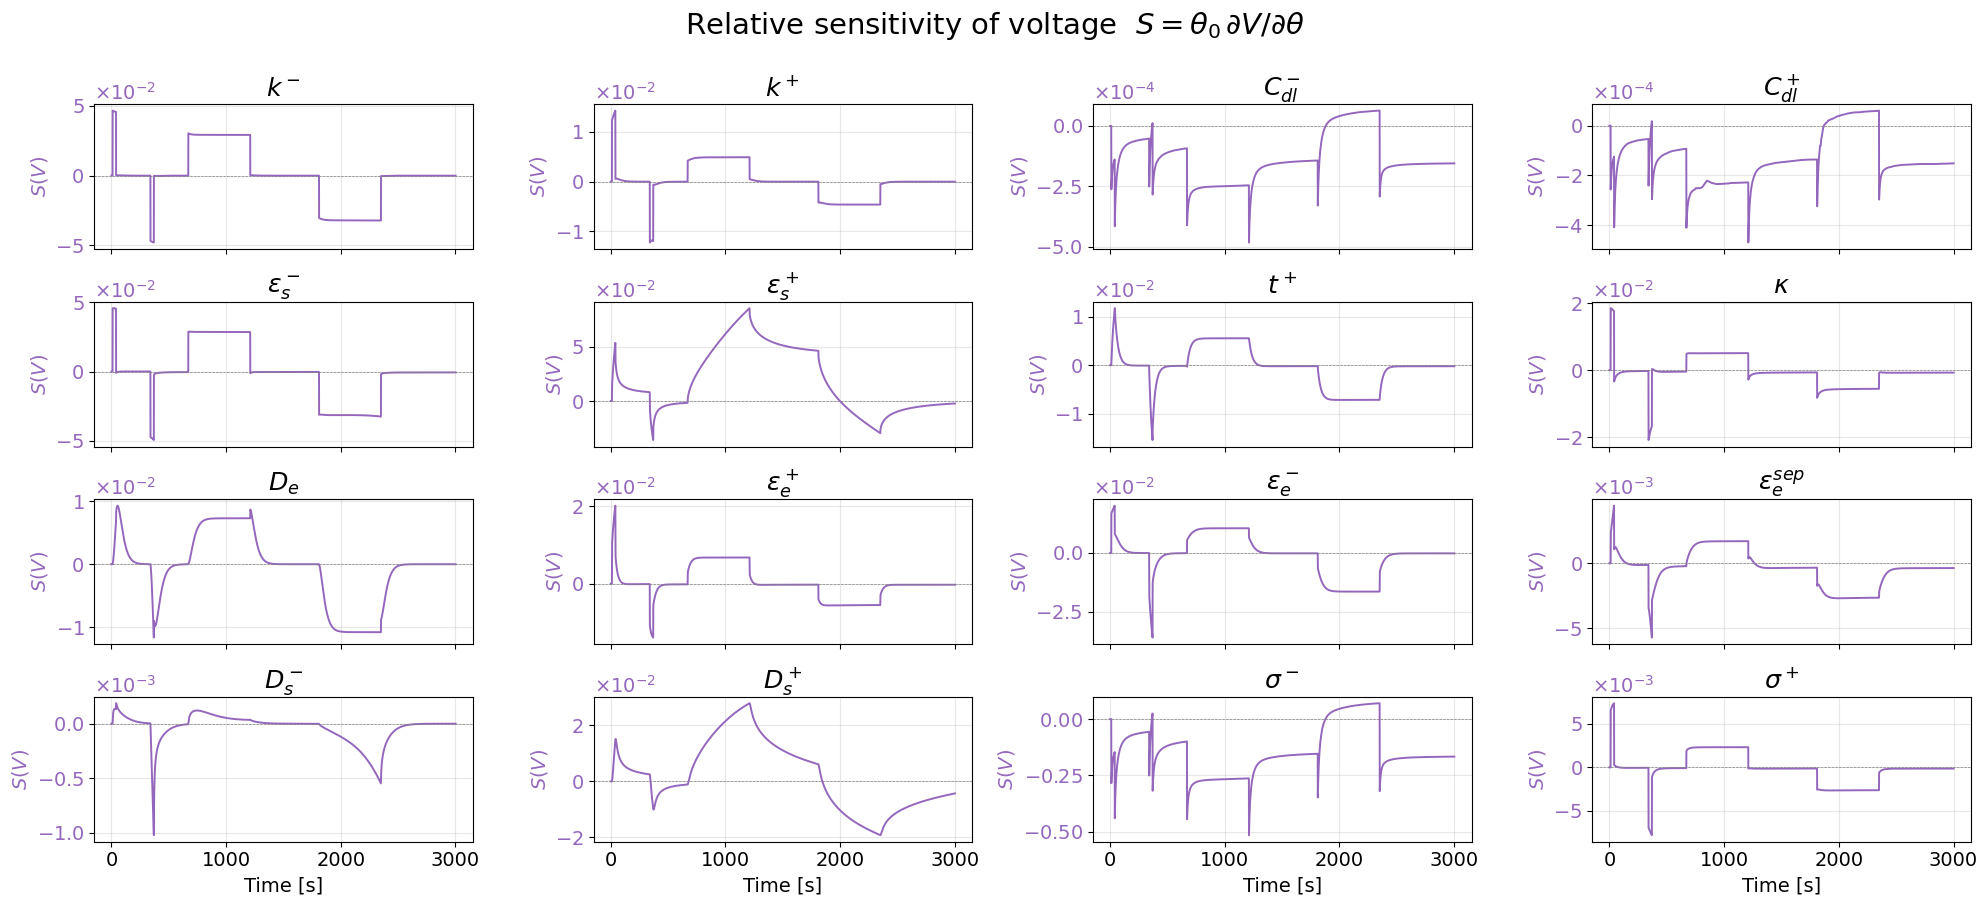

In [4]:
from matplotlib.ticker import ScalarFormatter

# ══════════════════════════════════════════════════════════════
# Time-resolved semi-relative sensitivity  θ · ∂V/∂θ — 4×4 grid
# ══════════════════════════════════════════════════════════════
FS = 14                                    # ← 이거 하나만 바꾸면 전체 스케일

def set_sci(ax):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))


plot_items = [(name, S) for name, S in sdae_sens_ts.items() if S is not None]

n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9), sharex=True)
axes_flat = axes.flatten()

color_v = "tab:purple"

for idx, (name, S) in enumerate(plot_items):
    if idx >= n_rows * n_cols:
        break
    ax = axes_flat[idx]

    ax.plot(t_uniform, S, color=color_v, linewidth=1.4)
    ax.set_ylabel(r"$S(V)$", color=color_v, fontsize=FS)
    ax.tick_params(axis="y", labelcolor=color_v, labelsize=FS)
    ax.tick_params(axis="x", labelsize=FS)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    set_sci(ax)
    ax.yaxis.get_offset_text().set_color(color_v)
    ax.yaxis.get_offset_text().set_fontsize(FS)

    ax.set_title(param_labels[name], fontsize=FS*1.3, pad=6)

# 마지막 행 x label
for j in range(n_cols):
    bottom_idx = (n_rows - 1) * n_cols + j
    if bottom_idx < len(axes_flat):
        axes_flat[bottom_idx].set_xlabel("Time [s]", fontsize=FS)

# 빈 subplot 숨기기
for k in range(len(plot_items), n_rows * n_cols):
    axes_flat[k].axis("off")

fig.suptitle(
    r"Relative sensitivity of voltage  "
    r"$S = \theta_0\,\partial V/\partial\theta$",
    fontsize=FS*1.5, y=1.00
)
plt.tight_layout()
plt.show()

### dcs_bulk/dtheta

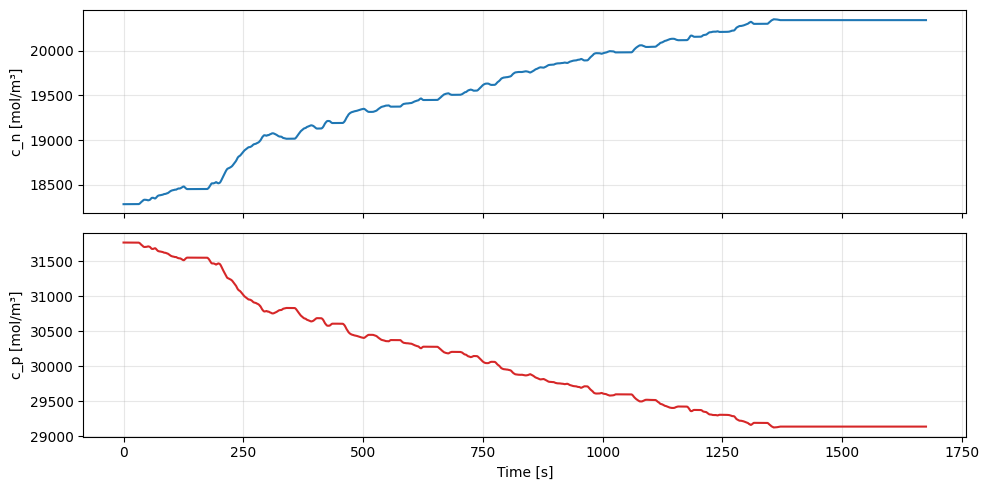

c_n range: [18280.8, 20354.1]
c_p range: [29128.0, 31763.2]


In [10]:
# c_p time-series 직접 확인
p_check = p_ref.copy()
sim_check = pybamm.Simulation(
    pybamm.lithium_ion.SPMe(options=MODEL_OPTIONS),
    experiment=experiment,
    parameter_values=p_check,
    solver=pybamm.IDAKLUSolver()
)
sol_check = sim_check.solve()

t_check = sol_check["Time [s]"].entries
c_n = sol_check["Average negative particle concentration [mol.m-3]"].entries
c_p = sol_check["Average positive particle concentration [mol.m-3]"].entries

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
axes[0].plot(t_check, c_n, color='tab:blue')
axes[0].set_ylabel("c_n [mol/m³]"); axes[0].grid(alpha=0.3)
axes[1].plot(t_check, c_p, color='tab:red')
axes[1].set_xlabel("Time [s]"); axes[1].set_ylabel("c_p [mol/m³]"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"c_n range: [{c_n.min():.1f}, {c_n.max():.1f}]")
print(f"c_p range: [{c_p.min():.1f}, {c_p.max():.1f}]")

In [5]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d


# ══════════════════════════════════════════════════════════════
# 전제: 이미 정의되어 있어야 할 것들
# ══════════════════════════════════════════════════════════════
# - p_ref (4개 callable 박힌 base parameter set)
# - j0_neg_with_mref, j0_pos_with_mref
# - kappa_nominal, De_nominal, m_ref_neg_nominal, m_ref_pos_nominal
# - param_labels, K_NEG, K_POS, mesh_dependent, sdae_params
# - experiment, MODEL_OPTIONS, t_uniform


# ══════════════════════════════════════════════════════════════
# 1. Sensitivity loop — c̄_s± time-series 저장
# ══════════════════════════════════════════════════════════════
sdae_data = {}

for name in sdae_params:
    try:
        p = p_ref.copy()
        
        # Target 별로 처리
        if name == K_NEG:
            p[K_NEG] = j0_neg_with_mref
            nominal_val = m_ref_neg_nominal
        elif name == K_POS:
            p[K_POS] = j0_pos_with_mref
            nominal_val = m_ref_pos_nominal
        else:
            val = p[name]
            if callable(val):
                raise ValueError(f"{name} still callable")
            nominal_val = float(val)
            p.update({name: "[input]"})
        
        inputs = {name: nominal_val}
        
        model_ = pybamm.lithium_ion.SPMe(options=MODEL_OPTIONS)
        solver_ = pybamm.IDAKLUSolver()
        sim_ = pybamm.Simulation(model_, experiment=experiment,
                                  parameter_values=p, solver=solver_)
        sol_ = sim_.solve(
            inputs=inputs,
            calculate_sensitivities=True,
        )
        
        # Time-series 추출
        t_ = sol_["Time [s]"].entries
        n_t = len(t_)
        
        sens_cn = np.asarray(
            sol_["Average negative particle concentration [mol.m-3]"]
            .sensitivities[name]
        ).flatten()[:n_t]
        sens_cp = np.asarray(
            sol_["Average positive particle concentration [mol.m-3]"]
            .sensitivities[name]
        ).flatten()[:n_t]
        
        # Uniform grid 에 interp
        sens_cn_u = interp1d(t_, sens_cn, kind='linear',
                              fill_value='extrapolate',
                              bounds_error=False)(t_uniform)
        sens_cp_u = interp1d(t_, sens_cp, kind='linear',
                              fill_value='extrapolate',
                              bounds_error=False)(t_uniform)
        
        # Semi-relative
        S_cn = nominal_val * sens_cn_u   # [mol/m³]
        S_cp = nominal_val * sens_cp_u   # [mol/m³]
        
        sdae_data[name] = {
            "label":   param_labels[name],
            "nominal": nominal_val,
            "S_cn":    S_cn,
            "S_cp":    S_cp,
        }
        print(f"✅ {param_labels[name]}")
    
    except Exception as e:
        print(f"❌ {param_labels[name]}: {str(e)[:60]}")


✅ $k^-$
✅ $k^+$
✅ $C_{dl}^-$
✅ $C_{dl}^+$
✅ $\varepsilon_s^-$
✅ $\varepsilon_s^+$
✅ $t^+$
✅ $\kappa$
✅ $D_e$
✅ $\varepsilon_e^+$
✅ $\varepsilon_e^-$
✅ $\varepsilon_e^{sep}$
✅ $D_s^-$
✅ $D_s^+$
✅ $\sigma^-$
✅ $\sigma^+$


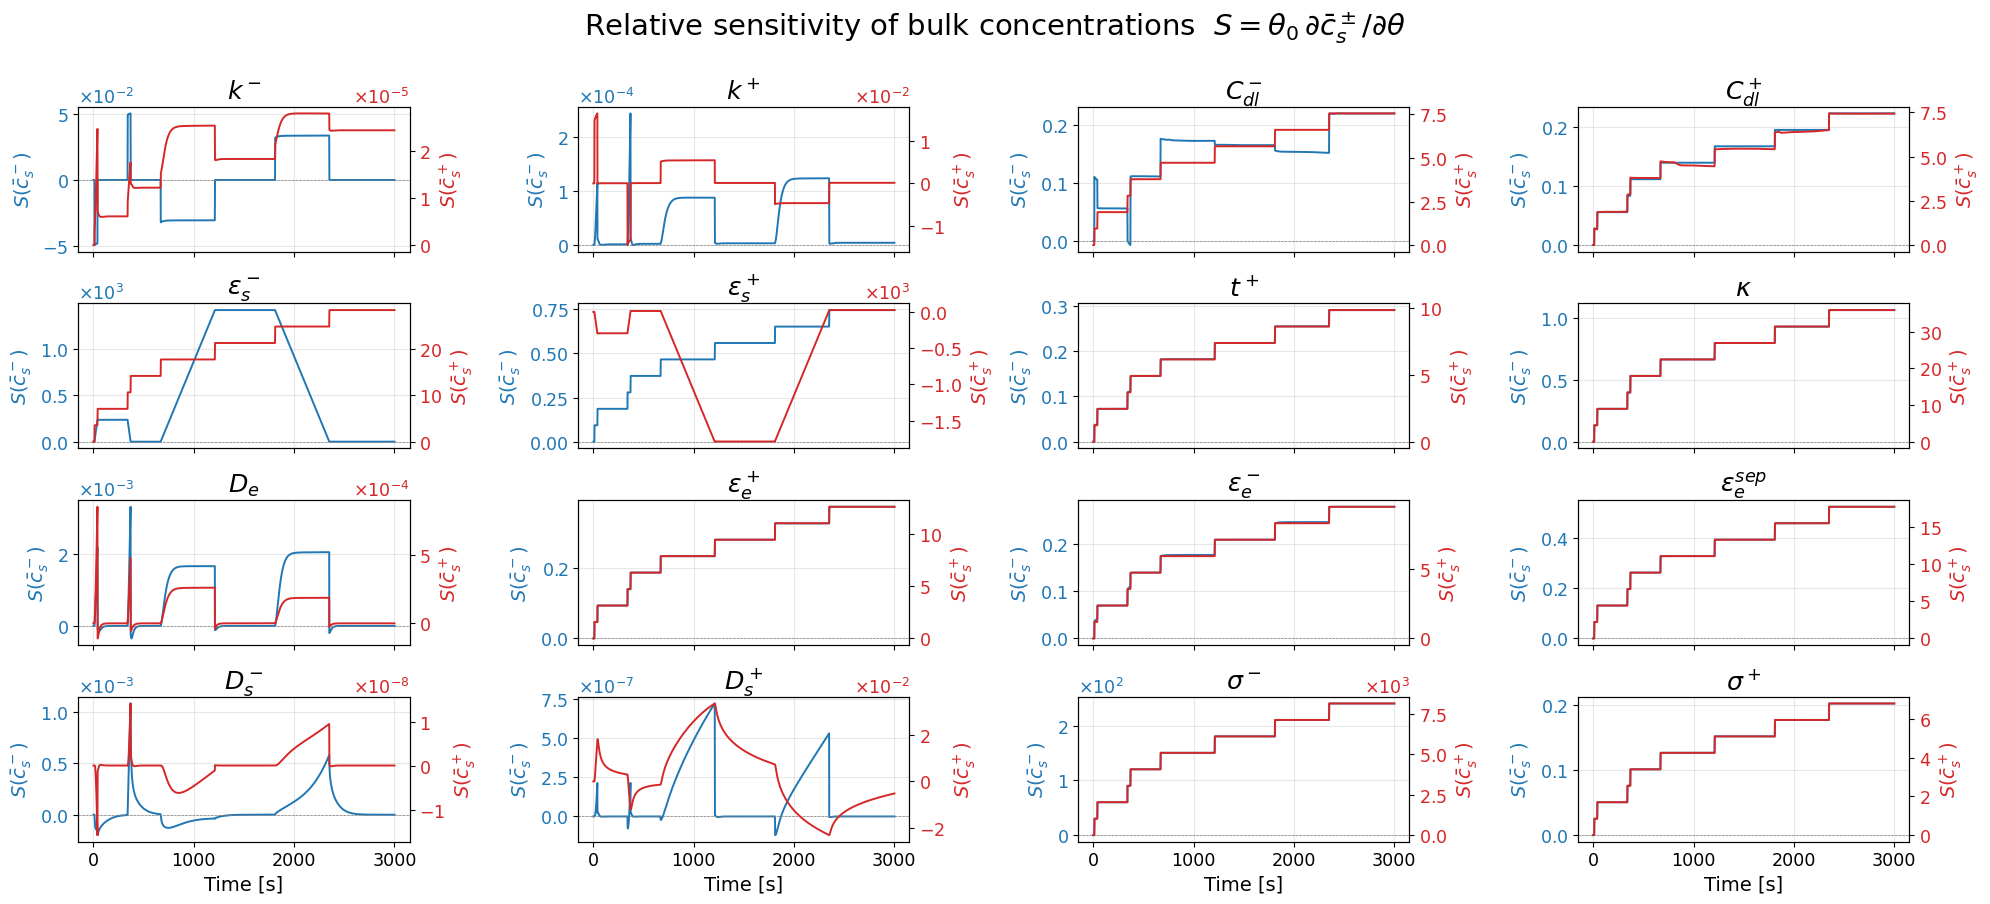

In [6]:
# ══════════════════════════════════════════════════════════════
# 2. Plot — 4×4 grid
# ══════════════════════════════════════════════════════════════
FS = 14                                    # ← 이거 하나만 바꾸면 전체 스케일

def set_sci(ax):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))


n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9), sharex=True)
axes_flat = axes.flatten()

color_n = "tab:blue"
color_p = "tab:red"

for idx, (name, d) in enumerate(sdae_data.items()):
    if idx >= n_rows * n_cols:
        break
    ax = axes_flat[idx]

    # 좌축: c̄_s^-
    ax.plot(t_uniform, d["S_cn"], color=color_n, linewidth=1.4)
    ax.set_ylabel(r"$S(\bar{c}_s^-)$", color=color_n, fontsize=FS)
    ax.tick_params(axis="y", labelcolor=color_n, labelsize=FS*0.9)
    ax.tick_params(axis="x", labelsize=FS*0.9)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    set_sci(ax)
    ax.yaxis.get_offset_text().set_color(color_n)
    ax.yaxis.get_offset_text().set_fontsize(FS*0.9)

    # 우축: c̄_s^+
    ax_r = ax.twinx()
    ax_r.plot(t_uniform, d["S_cp"], color=color_p, linewidth=1.4)
    ax_r.set_ylabel(r"$S(\bar{c}_s^+)$", color=color_p, fontsize=FS)
    ax_r.tick_params(axis="y", labelcolor=color_p, labelsize=FS*0.9)
    set_sci(ax_r)
    ax_r.yaxis.get_offset_text().set_color(color_p)
    ax_r.yaxis.get_offset_text().set_fontsize(FS*0.9)

    ax.set_title(d["label"], fontsize=FS*1.3, pad=6)

# 마지막 행에 x label
for j in range(n_cols):
    bottom_idx = (n_rows - 1) * n_cols + j
    if bottom_idx < len(axes_flat):
        axes_flat[bottom_idx].set_xlabel("Time [s]", fontsize=FS)

# 빈 subplot 숨기기
for k in range(len(sdae_data), n_rows * n_cols):
    axes_flat[k].axis("off")

fig.suptitle(
    r"Relative sensitivity of bulk concentrations  "
    r"$S = \theta_0\,\partial\bar{c}_s^\pm/\partial\theta$",
    fontsize=FS*1.5, y=1.00
)
plt.tight_layout()
plt.show()

#### FD

✅ $k^-$
✅ $k^+$
✅ $C_{dl}^-$
✅ $C_{dl}^+$
✅ $\varepsilon_s^-$
✅ $\varepsilon_s^+$
✅ $t^+$
✅ $\kappa$
✅ $D_e$
✅ $\varepsilon_e^+$
✅ $\varepsilon_e^-$
✅ $\varepsilon_e^{sep}$
✅ $D_s^-$
✅ $D_s^+$
✅ $\sigma^-$
✅ $\sigma^+$


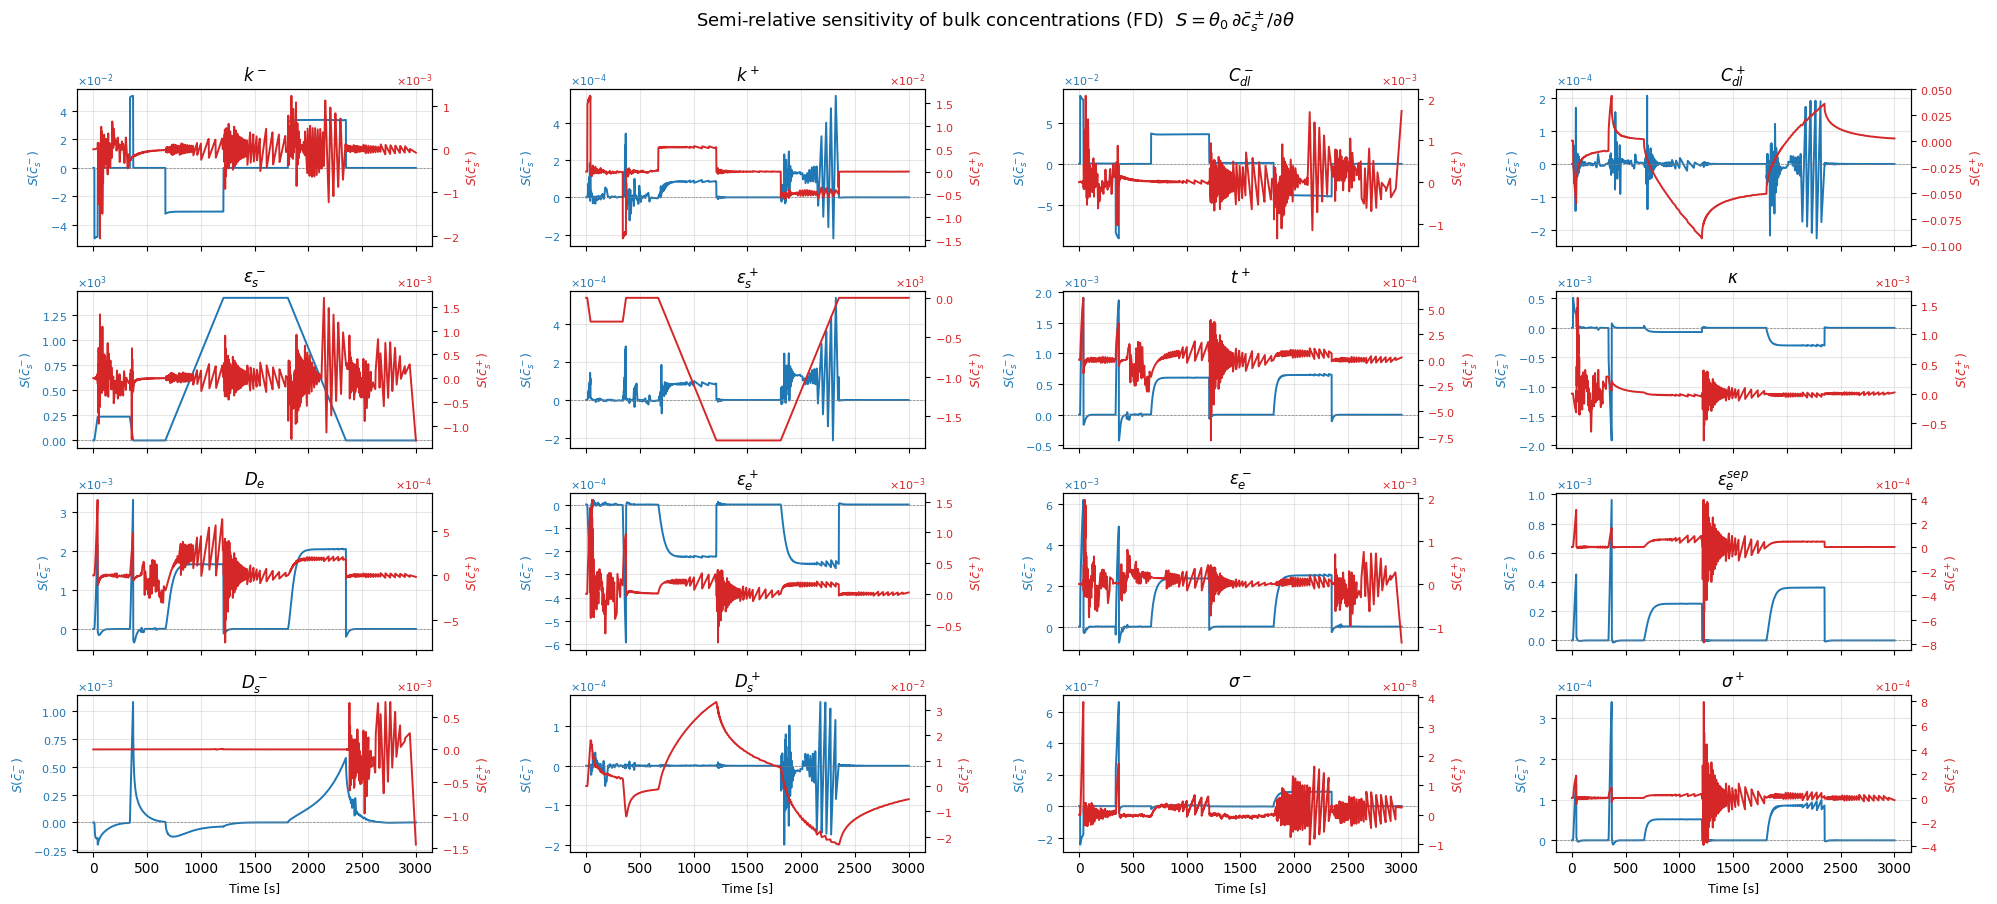

In [12]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d


# ══════════════════════════════════════════════════════════════
# 전제: 이미 정의되어 있어야 할 것들
# ══════════════════════════════════════════════════════════════
# - p_ref (4개 callable + SOC 박힌 base parameter set)
# - kappa_nominal, De_nominal, m_ref_neg_nominal, m_ref_pos_nominal
# - param_labels, K_NEG, K_POS, mesh_dependent, sdae_params
# - experiment, MODEL_OPTIONS, t_uniform


# ══════════════════════════════════════════════════════════════
# 1. FD sensitivity loop — c̄_s± time-series 저장
# ══════════════════════════════════════════════════════════════

FRAC = 0.01

def solve_with_perturbation(name, val):
    """name 파라미터를 val 로 perturb 한 simulation 결과 반환"""
    p = p_ref.copy()
    
    if name == K_NEG:
        # k⁻ target: m_ref_neg 값을 val 로 박은 j0 함수
        def j0_n(c_e, c_s_surf, c_s_max, T):
            arrh = pybamm.exp(35000/pybamm.constants.R*(1/298.15-1/T))
            return val * arrh * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5
        p[K_NEG] = j0_n
    elif name == K_POS:
        # k⁺ target: m_ref_pos 값을 val 로 박은 j0 함수
        def j0_p(c_e, c_s_surf, c_s_max, T):
            arrh = pybamm.exp(17800/pybamm.constants.R*(1/298.15-1/T))
            return val * arrh * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf)**0.5
        p[K_POS] = j0_p
    else:
        p[name] = val
    
    sim = pybamm.Simulation(
        pybamm.lithium_ion.SPMe(options=MODEL_OPTIONS),
        experiment=experiment,
        parameter_values=p,
        solver=pybamm.IDAKLUSolver()
    )
    sol = sim.solve()
    
    t_ = sol["Time [s]"].entries
    c_n = sol["Average negative particle concentration [mol.m-3]"].entries
    c_p = sol["Average positive particle concentration [mol.m-3]"].entries
    return t_, c_n, c_p


fd_data = {}

for name in sdae_params:
    try:
        # Nominal 값 결정
        if name == K_NEG:
            nominal_val = m_ref_neg_nominal
        elif name == K_POS:
            nominal_val = m_ref_pos_nominal
        else:
            val = p_ref[name]
            if callable(val):
                raise ValueError(f"{name} still callable")
            nominal_val = float(val)
        
        # Central FD: ±frac perturb
        t_p, cn_p, cp_p = solve_with_perturbation(name, nominal_val * (1 + FRAC))
        t_m, cn_m, cp_m = solve_with_perturbation(name, nominal_val * (1 - FRAC))
        
        # Uniform grid 에 interp
        cn_p_u = interp1d(t_p, cn_p, kind='linear',
                           fill_value='extrapolate', bounds_error=False)(t_uniform)
        cn_m_u = interp1d(t_m, cn_m, kind='linear',
                           fill_value='extrapolate', bounds_error=False)(t_uniform)
        cp_p_u = interp1d(t_p, cp_p, kind='linear',
                           fill_value='extrapolate', bounds_error=False)(t_uniform)
        cp_m_u = interp1d(t_m, cp_m, kind='linear',
                           fill_value='extrapolate', bounds_error=False)(t_uniform)
        
        # Central FD: ∂c/∂θ ≈ (c+ - c-) / (2·frac·θ)
        dcn_dtheta = (cn_p_u - cn_m_u) / (2 * FRAC * nominal_val)
        dcp_dtheta = (cp_p_u - cp_m_u) / (2 * FRAC * nominal_val)
        
        # Semi-relative: θ₀ · ∂c/∂θ
        S_cn = nominal_val * dcn_dtheta
        S_cp = nominal_val * dcp_dtheta
        
        fd_data[name] = {
            "label":   param_labels[name],
            "nominal": nominal_val,
            "S_cn":    S_cn,
            "S_cp":    S_cp,
        }
        print(f"✅ {param_labels[name]}")
    
    except Exception as e:
        print(f"❌ {param_labels[name]}: {str(e)[:60]}")


# ══════════════════════════════════════════════════════════════
# 2. Plot — 4×4 grid (위 SDAE plot 과 동일 구조)
# ══════════════════════════════════════════════════════════════
def set_sci(ax):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))


n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9), sharex=True)
axes_flat = axes.flatten()

color_n = "tab:blue"
color_p = "tab:red"

for idx, (name, d) in enumerate(fd_data.items()):
    if idx >= n_rows * n_cols:
        break
    ax = axes_flat[idx]

    # 좌축: c̄_s^-
    ax.plot(t_uniform, d["S_cn"], color=color_n, linewidth=1.4)
    ax.set_ylabel(r"$S(\bar{c}_s^-)$", color=color_n, fontsize=9)
    ax.tick_params(axis="y", labelcolor=color_n, labelsize=8)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    set_sci(ax)
    ax.yaxis.get_offset_text().set_color(color_n)
    ax.yaxis.get_offset_text().set_fontsize(8)

    # 우축: c̄_s^+
    ax_r = ax.twinx()
    ax_r.plot(t_uniform, d["S_cp"], color=color_p, linewidth=1.4)
    ax_r.set_ylabel(r"$S(\bar{c}_s^+)$", color=color_p, fontsize=9)
    ax_r.tick_params(axis="y", labelcolor=color_p, labelsize=8)
    set_sci(ax_r)
    ax_r.yaxis.get_offset_text().set_color(color_p)
    ax_r.yaxis.get_offset_text().set_fontsize(8)

    ax.set_title(d["label"], fontsize=12, pad=6)

# 마지막 행에 x label
for j in range(n_cols):
    bottom_idx = (n_rows - 1) * n_cols + j
    if bottom_idx < len(axes_flat):
        axes_flat[bottom_idx].set_xlabel("Time [s]", fontsize=9)

# 빈 subplot 숨기기
for k in range(len(fd_data), n_rows * n_cols):
    axes_flat[k].axis("off")

fig.suptitle(
    r"Semi-relative sensitivity of bulk concentrations (FD)  "
    r"$S = \theta_0\,\partial\bar{c}_s^\pm/\partial\theta$",
    fontsize=13, y=1.00
)
plt.tight_layout()
plt.show()

In [ ]:
for pname in param_labels:
    val = pybamm.ParameterValues("Chen2020")[pname]
    kind = "callable" if callable(val) else f"scalar ({val})"
    print(f"{kind:20s}  {pname}")

## Local (Central Difference)

In [ ]:
# ══════════════════════════════════════════════════════════════
# Local Sensitivity — Central Difference (5% perturbation)
# ══════════════════════════════════════════════════════════════
func_params = [
    "Negative electrode exchange-current density [A.m-2]",
    "Positive electrode exchange-current density [A.m-2]",
    "Electrolyte conductivity [S.m-1]",
    "Electrolyte diffusivity [m2.s-1]",
]


def run_nominal():
    p = base_param.copy()
    model_ = pybamm.lithium_ion.DFN()
    solver_ = pybamm.IDAKLUSolver()
    sim_ = pybamm.Simulation(model_, experiment=experiment,
                              parameter_values=p, solver=solver_)
    sol_ = sim_.solve()
    return sol_["Voltage [V]"].entries


def run_perturbed(name, direction, perturbation=0.05):
    p = base_param.copy()
    s = 1 + direction * perturbation

    if name in func_params:
        original_func = base_param[name]
        p[name] = lambda *args, sc=s, f=original_func: sc * f(*args)
    else:
        p[name] = float(base_param[name]) * s

    try:
        model_ = pybamm.lithium_ion.DFN()
        solver_ = pybamm.IDAKLUSolver()
        sim_ = pybamm.Simulation(model_, experiment=experiment,
                                  parameter_values=p, solver=solver_)
        sol_ = sim_.solve()
        return sol_["Voltage [V]"].entries
    except:
        return None


experiment = make_experiment(profile_id=4, soc=0.5)

# nominal 실행
V_nom_local = run_nominal()

# 각 파라미터별 local sensitivity 계산
local_sensitivity = {}

for name in param_names:
    V_upper = run_perturbed(name, +1)
    V_lower = run_perturbed(name, -1)

    if V_upper is None or V_lower is None:
        local_sensitivity[name] = np.nan
        print(f"{param_labels[name]}: FAILED")
        continue

    n_min = min(len(V_upper), len(V_lower), len(V_nom_local))
    S = (V_upper[:n_min] - V_lower[:n_min]) / (2 * 0.05 * V_nom_local[:n_min])
    local_sensitivity[name] = float(np.sqrt(np.mean(S**2)))
    print(f"{param_labels[name]}: {local_sensitivity[name]:.4f}")


In [ ]:
# ══════════════════════════════════════════════════════════════
# 시각화 — Local only
# ══════════════════════════════════════════════════════════════
labels = [param_labels[k] for k in param_names]
local_vals = np.array([local_sensitivity[k] for k in param_names])
local_norm = local_vals / np.nansum(local_vals)

x = np.arange(len(param_names))
w = 0.5

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(x, local_norm, width=w, color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Relative Sensitivity")
ax.set_title("Local Sensitivity Analysis (Central Difference, 5% perturbation) — DFN Chen2020 NMC")
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

local_results = {
    "local_sensitivity": local_sensitivity,
    "local_vals": local_vals,
    "local_norm": local_norm,
    "param_labels": param_labels,
    "param_names": param_names,
    "perturbation": 0.05,
    "profile_id": 4,
    "soc": 0.5,
}

with open("local_sensitivity_profile4_soc05.pkl", "wb") as f:
    pickle.dump(local_results, f)

print("Saved.")

## Global (Sobol)

In [ ]:
import pybamm
import numpy as np
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze
from joblib import Parallel, delayed
from tqdm import tqdm as tqdm_std
import time
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════
# 0. Setup
# ══════════════════════════════════════════════════════════════
model = pybamm.lithium_ion.DFN()
base_param = pybamm.ParameterValues("Chen2020")
solver = pybamm.IDAKLUSolver()

param_labels = {
    "Negative electrode exchange-current density [A.m-2]": r"$k^-$",
    "Positive electrode exchange-current density [A.m-2]": r"$k^+$",
    "Negative electrode double-layer capacity [F.m-2]": r"$C_{dl}^-$",
    "Positive electrode double-layer capacity [F.m-2]": r"$C_{dl}^+$",
    "Cation transference number": r"$t^+$",
    "Electrolyte conductivity [S.m-1]": r"$\kappa$",
    "Electrolyte diffusivity [m2.s-1]": r"$D_e$",
    "Positive electrode porosity": r"$\varepsilon_e^+$",
    "Negative electrode porosity": r"$\varepsilon_e^-$",
    "Separator porosity": r"$\varepsilon_e^{sep}$",
    "Negative particle diffusivity [m2.s-1]": r"$D_s^-$",
    "Positive particle diffusivity [m2.s-1]": r"$D_s^+$",
    "Negative particle radius [m]": r"$R_s^-$",
    "Positive particle radius [m]": r"$R_s^+$",
}

param_names = list(param_labels.keys())

# ══════════════════════════════════════════════════════════════
# 1. 파라미터 분류
# ══════════════════════════════════════════════════════════════
func_params = [
    "Negative electrode exchange-current density [A.m-2]",
    "Positive electrode exchange-current density [A.m-2]",
    "Electrolyte conductivity [S.m-1]",
    "Electrolyte diffusivity [m2.s-1]",
]

epsilon_params = [
    "Positive electrode porosity",
    "Negative electrode porosity",
    "Separator porosity",
]

order1_func_params = [
    "Negative electrode exchange-current density [A.m-2]",
    "Positive electrode exchange-current density [A.m-2]",
    "Electrolyte diffusivity [m2.s-1]",
]

# ══════════════════════════════════════════════════════════════
# 2. Bounds 설정
# ══════════════════════════════════════════════════════════════
bounds = []
for k in param_names:
    if k in order1_func_params:
        # k^-, k^+, D_e: ±1 order scaling (0.1 ~ 10)
        bounds.append([0.1, 10.0])
    elif k == "Electrolyte conductivity [S.m-1]":
        # κ: 0.5 ~ 1.5 scaling
        bounds.append([0.5, 1.5])
    elif k in epsilon_params:
        # porosity: ±0.2
        nom = float(base_param[k])
        bounds.append([max(0.01, nom - 0.2), min(0.99, nom + 0.2)])
    elif k == "Cation transference number":
        # t+: ±0.1
        nom = float(base_param[k])
        bounds.append([max(0.01, nom - 0.1), min(0.99, nom + 0.1)])
    elif k in ["Negative electrode double-layer capacity [F.m-2]",
               "Positive electrode double-layer capacity [F.m-2]"]:
        # ±1 order
        nom = float(base_param[k])
        bounds.append([np.log10(nom) - 1, np.log10(nom) + 1])
    elif k in ["Negative particle radius [m]",
               "Positive particle radius [m]"]:
        # R_s^-, R_s^+: ±1 order
        nom = float(base_param[k])
        bounds.append([np.log10(nom) - 1, np.log10(nom) + 1])
    else:
        # D_s^-, D_s^+: ±2 order
        nom = float(base_param[k])
        bounds.append([np.log10(nom) - 2, np.log10(nom) + 2])

problem = {
    "num_vars": len(param_names),
    "names": param_names,
    "bounds": bounds,
}

# bounds 확인
print("Parameter bounds:")
for i, k in enumerate(param_names):
    lo, hi = bounds[i]
    if k in func_params:
        print(f"  {param_labels[k]}: scale [{lo:.2f}, {hi:.2f}]")
    elif k in epsilon_params or k == "Cation transference number":
        print(f"  {param_labels[k]}: [{lo:.4f}, {hi:.4f}]")
    else:
        print(f"  {param_labels[k]}: [{10**lo:.3e}, {10**hi:.3e}]")

# ══════════════════════════════════════════════════════════════
# 3. Nominal 시뮬레이션 (RMSE 기준점)
# ══════════════════════════════════════════════════════════════
soc = 0.5
experiment = make_experiment(profile_id=4, soc=soc)

sim_nom = pybamm.Simulation(model, experiment=experiment,
                             parameter_values=base_param, solver=solver)
sol_nom = sim_nom.solve()
V_nom = sol_nom["Voltage [V]"].entries

# ★ 추가: 고정 time grid (Streb의 voltage(t) per-timestep GSA를 위해)
t_eval = sol_nom.t
N_T = len(t_eval)
print(f"Time grid: {N_T} points")

# ══════════════════════════════════════════════════════════════
# 4. Sobol 샘플 생성
# ══════════════════════════════════════════════════════════════
n = 500
X = sobol_sample.sample(problem, n)
print(f"\nTotal simulations: {len(X)}")  # (14+2)*100 = 1600

# ══════════════════════════════════════════════════════════════
# 5. 단일 시뮬레이션 함수
# ══════════════════════════════════════════════════════════════
def run_single(theta):
    p = base_param.copy()

    for i, name in enumerate(param_names):
        if name in func_params:
            scale = theta[i]
            original_func = base_param[name]
            p[name] = lambda *args, s=scale, f=original_func: s * f(*args)
        elif name in epsilon_params:
            p[name] = float(theta[i])
        elif name == "Cation transference number":
            p[name] = float(theta[i])
        else:
            p[name] = float(10 ** theta[i])

    try:
        model_ = pybamm.lithium_ion.DFN()
        solver_ = pybamm.IDAKLUSolver()
        sim_ = pybamm.Simulation(model_, experiment=experiment,
                                  parameter_values=p, solver=solver_)
        sol_ = sim_.solve()
        V_ = sol_["Voltage [V]"].entries
        # ★ Streb-style: voltage trajectory 자체를 반환
        V_interp = np.interp(t_eval, sol_.t, V_)
        return V_interp
    except Exception:
        return np.full(N_T, np.nan)

# ══════════════════════════════════════════════════════════════
# 6. 병렬 실행
# ══════════════════════════════════════════════════════════════
t0 = time.time()
Y = np.array(
    Parallel(n_jobs=20, verbose=5)(
        delayed(run_single)(X[i]) for i in range(len(X))
    )
)
print(f"Elapsed: {time.time()-t0:.1f}s")
n_failed = np.isnan(Y).any(axis=1).sum()
print(f"Failed trajectories: {n_failed}/{len(Y)}")


# ══════════════════════════════════════════════════════════════
# 7. Sobol 분석 (Streb-style: per-timestep + nearest-neighbor crash substitution)
# ══════════════════════════════════════════════════════════════
from scipy.spatial.distance import cdist

# (a) Nearest-neighbor substitution for crashed samples (Streb Sec 3.1)
failed_mask = np.isnan(Y).any(axis=1)
ok_mask = ~failed_mask
print(f"Failed: {failed_mask.sum()}, OK: {ok_mask.sum()}")

if failed_mask.sum() > 0:
    # Parameter space 거리로 nearest neighbor 찾기
    dist = cdist(X[failed_mask], X[ok_mask])  # (n_fail, n_ok)
    nn_idx = dist.argmin(axis=1)
    Y_clean = Y.copy()
    Y_clean[failed_mask] = Y[ok_mask][nn_idx]
else:
    Y_clean = Y.copy()

# (b) Per-timestep Sobol analysis
S1_time = np.zeros((N_T, len(param_names)))
ST_time = np.zeros((N_T, len(param_names)))

for k in range(N_T):
    Si_k = sobol_analyze.analyze(problem, Y_clean[:, k], print_to_console=False)
    S1_time[k] = Si_k["S1"]
    ST_time[k] = Si_k["ST"]

# Streb-style time-averaged sensitivity (Eq. 48 spirit)
S1_avg = S1_time.mean(axis=0)
ST_avg = ST_time.mean(axis=0)

# ══════════════════════════════════════════════════════════════
# 8. 결과 출력
# ══════════════════════════════════════════════════════════════
labels = list(param_labels.values())

print("\nFirst-order (S1, time-averaged):")
for name, s1 in zip(labels, S1_avg):
    print(f"  {name}: {s1:.4f}")

print("\nTotal-order (ST, time-averaged):")
for name, st in zip(labels, ST_avg):
    print(f"  {name}: {st:.4f}")


In [ ]:
# ══════════════════════════════════════════════════════════════
# 9. 시각화
# ══════════════════════════════════════════════════════════════
x = np.arange(len(param_names))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(x - w/2, S1_avg, width=w, label="S1 (first-order)", color="steelblue")
ax.bar(x + w/2, ST_avg, width=w, label="ST (total-order)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Sobol Index")
ax.set_title("Global Sensitivity Analysis (Sobol) — DFN Chen2020 NMC")
ax.legend()
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# 10. Time-resolved 3-panel plot
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (a) Sample voltage trajectories + nominal
ax = axes[0]
sample_idx = np.linspace(0, len(Y_clean)-1, 10).astype(int)
for j in sample_idx:
    ax.plot(t_eval, Y_clean[j], alpha=0.4, linewidth=0.8, color="gray")
ax.plot(t_eval, V_nom, "k-", linewidth=2, label="nominal")
ax.set_ylabel("Voltage [V]")
ax.set_title("(a) Voltage trajectories (10 random samples + nominal)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

# (b) Time-resolved S1
ax = axes[1]
top_k = 6
top_idx = np.argsort(S1_avg)[::-1][:top_k]
colors = plt.cm.tab10(np.linspace(0, 1, top_k))
for rank, i in enumerate(top_idx):
    ax.plot(t_eval, S1_time[:, i], 
            label=labels[i], color=colors[rank], linewidth=1.5)
ax.set_ylabel("$S_1(t)$")
ax.set_title(f"(b) First-order Sobol (Top-{top_k})")
ax.legend(loc="best", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

# (c) Time-resolved ST
ax = axes[2]
top_idx_st = np.argsort(ST_avg)[::-1][:top_k]
for rank, i in enumerate(top_idx_st):
    ax.plot(t_eval, ST_time[:, i], 
            label=labels[i], color=colors[rank], linewidth=1.5)
ax.set_xlabel("Time [s]")
ax.set_ylabel("$S_T(t)$")
ax.set_title(f"(c) Total-order Sobol (Top-{top_k})")
ax.legend(loc="best", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pickle

results = {
    # GSA 결과
    "S1_time": S1_time,      # shape (N_T, 14): 시점별 first-order
    "ST_time": ST_time,      # shape (N_T, 14): 시점별 total-order
    "S1_avg": S1_avg,        # shape (14,): 시간 평균 (importance ranking)
    "ST_avg": ST_avg,        # shape (14,): 시간 평균
    
    # Raw simulation data (재분석용)
    "Y": Y,                  # shape (n_samples, N_T): voltage trajectories
    "Y_clean": Y_clean,      # NN substitution 적용된 버전
    "X": X,                  # shape (n_samples, 14): parameter samples
    
    # Setup info (재현용)
    "problem": problem,
    "param_labels": param_labels,
    "param_names": param_names,
    "bounds": bounds,
    "n": n,
    "t_eval": t_eval,
    "V_nom": V_nom,
    "soc_initial": soc,
    "profile_id": 4,
}

filename = f"sobol_results_n{n}_profile4_soc{int(soc*100):02d}.pkl"
with open(filename, "wb") as f:
    pickle.dump(results, f)

print(f"\nSaved: {filename}")